In [24]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt



In [25]:

DATA_DIR = Path("TUTORIAL_ROUND_1")

# Load all CSVs in TUTORIAL_ROUND_1 into one DataFrame.
# IMC tutorial data is semicolon-delimited.
files = sorted(DATA_DIR.glob("*.csv"))
frames = [pd.read_csv(f, sep=";").assign(source_file=f.name) for f in files]

df = pd.concat(frames, ignore_index=True)
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_3,mid_price,profit_and_loss,source_file,buyer,seller,symbol,currency,price,quantity
0,-1.0,0,TOMATOES,4999.0,5.0,4998.0,15.0,NaN,NaN,5013.0,...,NaN,5006.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
1,-1.0,0,EMERALDS,9992.0,14.0,9990.0,29.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
2,-1.0,100,EMERALDS,9992.0,11.0,9990.0,22.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
3,-1.0,100,TOMATOES,5000.0,8.0,4998.0,21.0,NaN,NaN,5013.0,...,NaN,5006.5,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN
4,-1.0,200,EMERALDS,9992.0,15.0,9990.0,20.0,NaN,NaN,10008.0,...,NaN,10000.0,0.0,prices_round_0_day_-1.csv,NaN,NaN,NaN,NaN,NaN,NaN


length : 41219

In [26]:
df.columns.tolist()


['day',
 'timestamp',
 'product',
 'bid_price_1',
 'bid_volume_1',
 'bid_price_2',
 'bid_volume_2',
 'bid_price_3',
 'bid_volume_3',
 'ask_price_1',
 'ask_volume_1',
 'ask_price_2',
 'ask_volume_2',
 'ask_price_3',
 'ask_volume_3',
 'mid_price',
 'profit_and_loss',
 'source_file',
 'buyer',
 'seller',
 'symbol',
 'currency',
 'price',
 'quantity']

signals to explore

In [27]:

df = df.sort_values(["product", "timestamp"]).reset_index(drop=True)
volume_cols = [
    "bid_volume_1", "bid_volume_2", "bid_volume_3",
    "ask_volume_1", "ask_volume_2", "ask_volume_3"
]

df[volume_cols] = df[volume_cols].fillna(0)
# Spread
df["spread"] = df["ask_price_1"] - df["bid_price_1"]

# Depth
df["bid_depth"] = df["bid_volume_1"] + df["bid_volume_2"] + df["bid_volume_3"]
df["ask_depth"] = df["ask_volume_1"] + df["ask_volume_2"] + df["ask_volume_3"]

# Imbalance
df["imbalance"] = (df["bid_depth"] - df["ask_depth"]) / (df["bid_depth"] + df["ask_depth"])

# Mid-price returns
df["mid_return"] = df.groupby("product")["mid_price"].diff()

# Rolling volatility (window=50 ticks)
df["volatility"] = df.groupby("product")["mid_return"].rolling(50).std().reset_index(level=0, drop=True)

# Microprice
df["microprice"] = (
    df["bid_price_1"] * df["ask_volume_1"] +
    df["ask_price_1"] * df["bid_volume_1"]
) / (df["bid_volume_1"] + df["ask_volume_1"])

In [28]:
# separate tomatoes + emeralds
tom = df[df["product"] == "TOMATOES"]
eme = df[df["product"] == "EMERALDS"]
def plot_series(data, column, title):
    plt.figure(figsize=(12,4))
    plt.plot(data["timestamp"], data[column])
    plt.title(title)
    plt.xlabel("timestamp")
    plt.ylabel(column)
    plt.grid(True)
    plt.show()



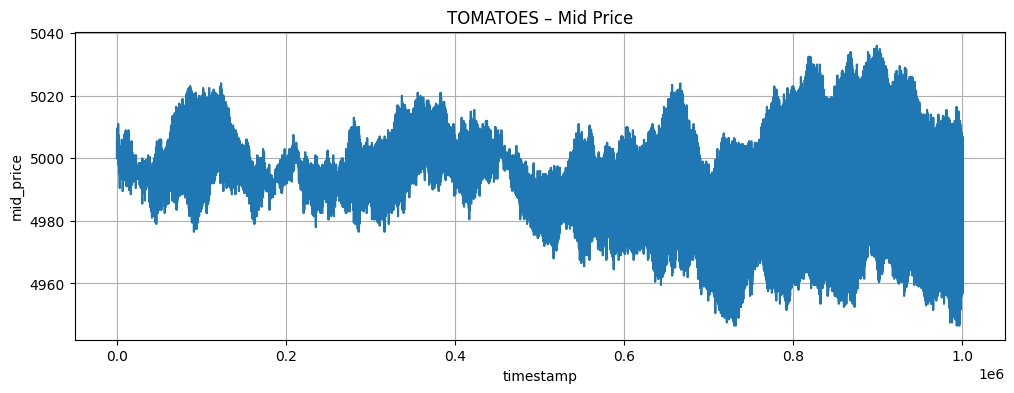

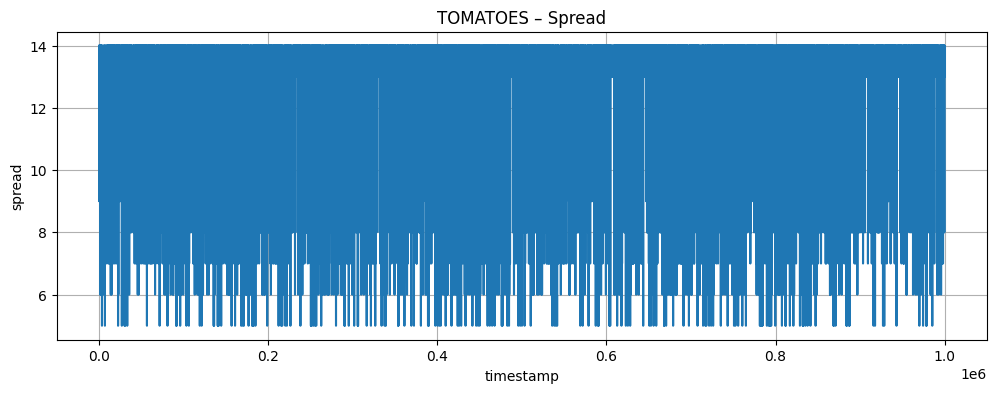

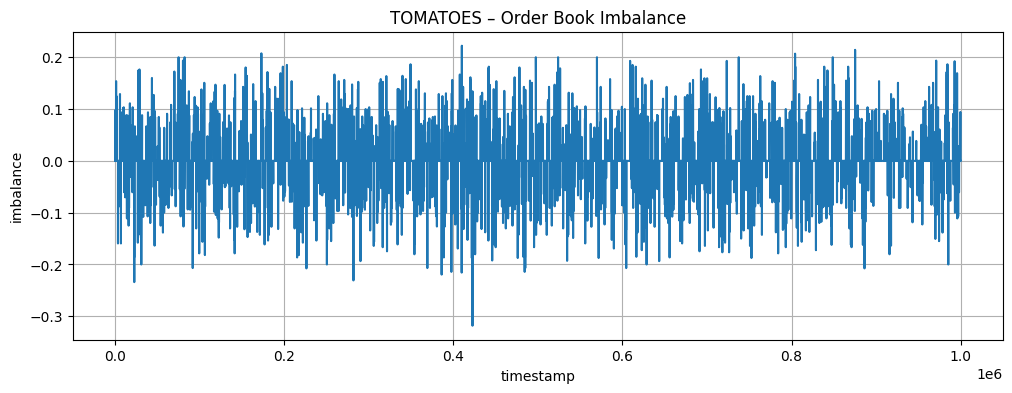

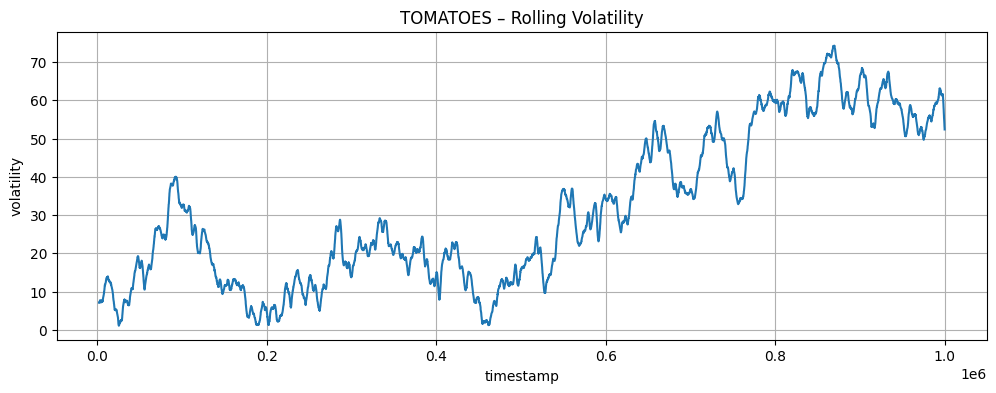

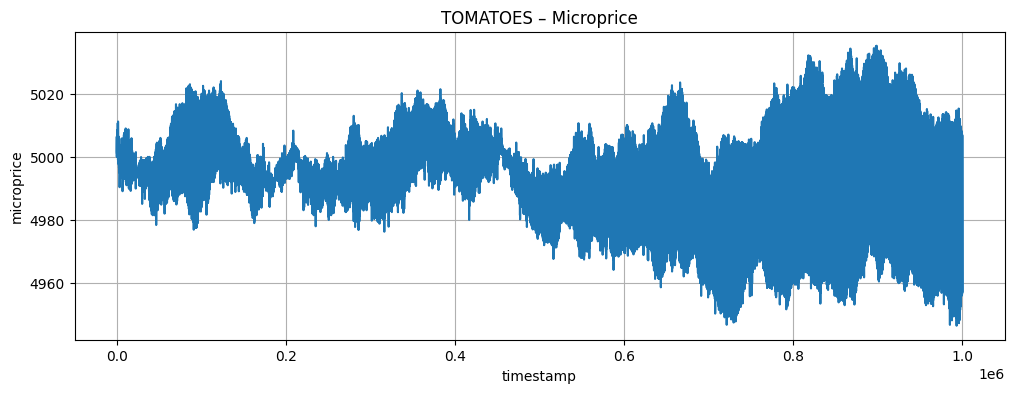

In [29]:
plot_series(tom, "mid_price", "TOMATOES – Mid Price")
plot_series(tom, "spread", "TOMATOES – Spread")
plot_series(tom, "imbalance", "TOMATOES – Order Book Imbalance")
plot_series(tom, "volatility", "TOMATOES – Rolling Volatility")
plot_series(tom, "microprice", "TOMATOES – Microprice")


In [30]:
tom["imbalance"].head()

20000    0.000000
20001    0.000000
20002    0.000000
20003    0.098039
20004    0.000000
Name: imbalance, dtype: float64

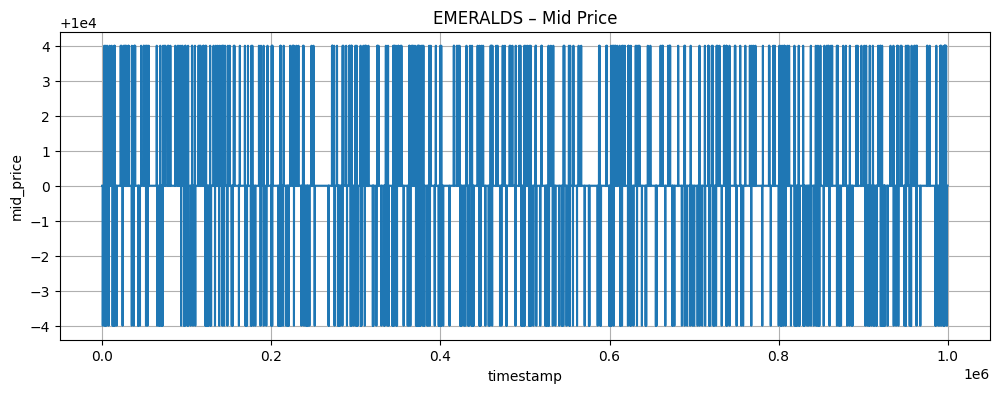

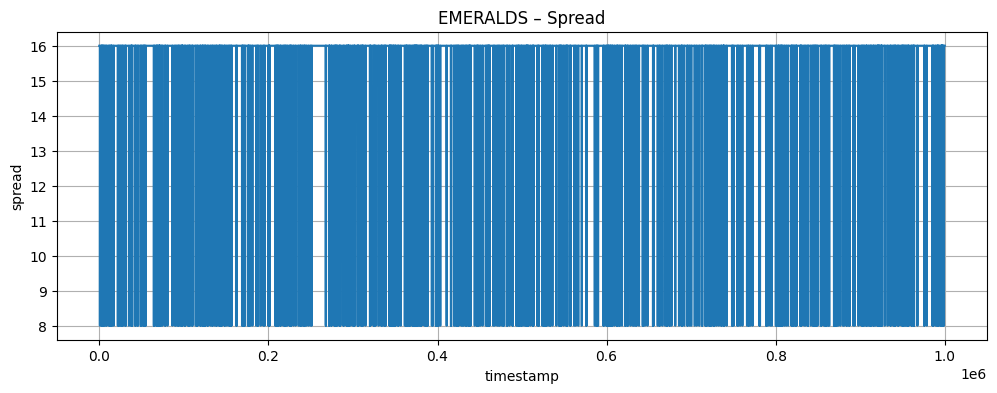

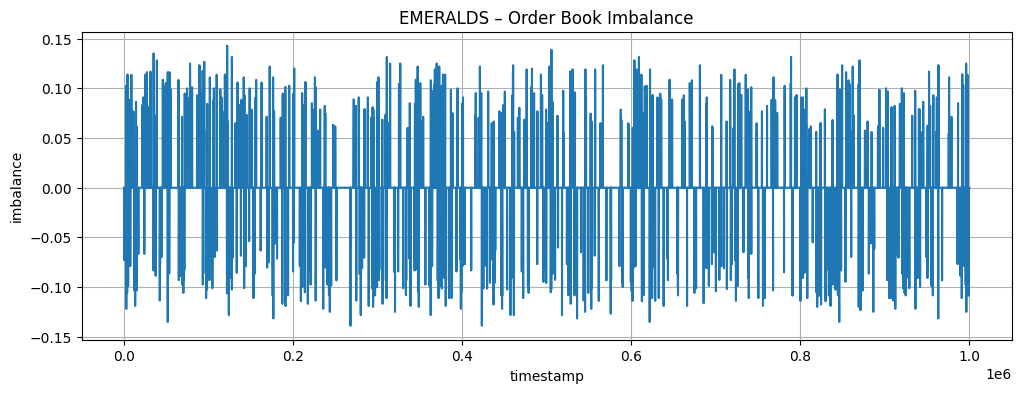

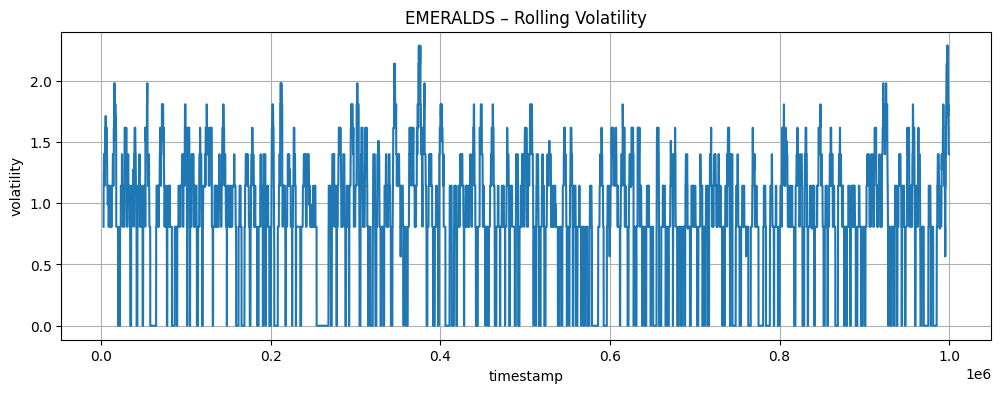

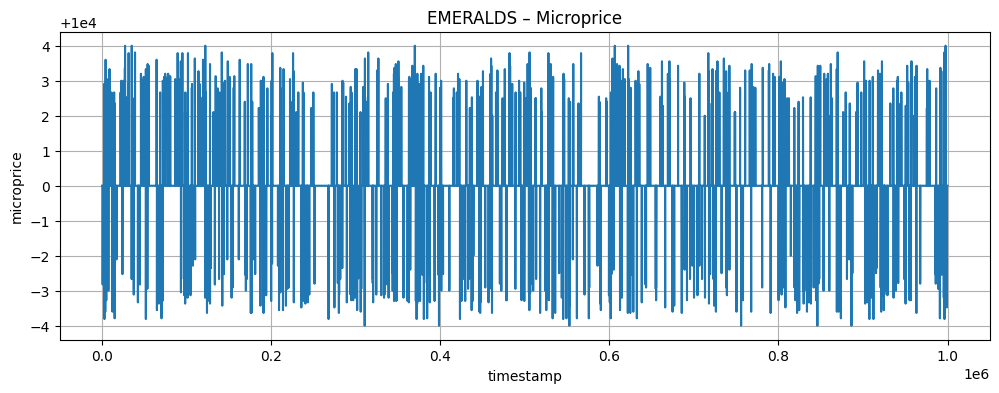

In [31]:
plot_series(eme, "mid_price", "EMERALDS – Mid Price")
plot_series(eme, "spread", "EMERALDS – Spread")
plot_series(eme, "imbalance", "EMERALDS – Order Book Imbalance")
plot_series(eme, "volatility", "EMERALDS – Rolling Volatility")
plot_series(eme, "microprice", "EMERALDS – Microprice")


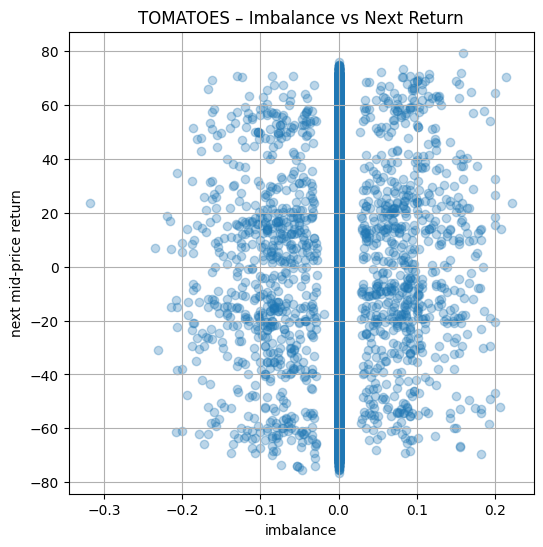

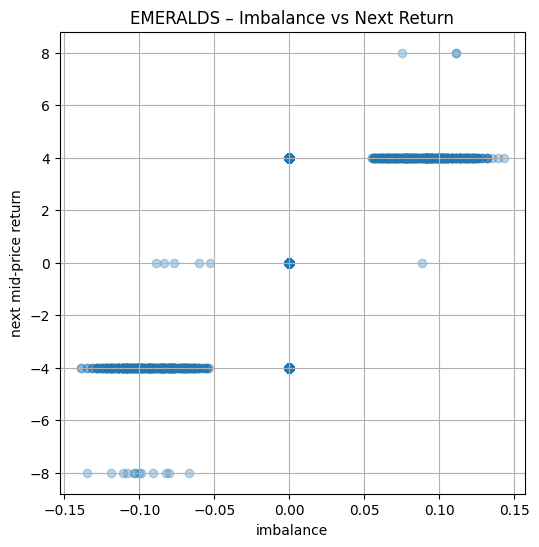

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(tom["imbalance"], tom["mid_return"], alpha=0.3)
plt.title("TOMATOES – Imbalance vs Next Return")
plt.xlabel("imbalance")
plt.ylabel("next mid-price return")
plt.grid(True)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(eme["imbalance"], eme["mid_return"], alpha=0.3)
plt.title("EMERALDS – Imbalance vs Next Return")
plt.xlabel("imbalance")
plt.ylabel("next mid-price return")
plt.grid(True)
plt.show()


## Modeling Trades

In [45]:
# Separate trades and prices data
trades_df = df[df['symbol'].notna()].copy()
prices_df = df[df['product'].notna()].copy()

# Clean trades data
trades_df['timestamp'] = trades_df['timestamp'].astype(int)
trades_df['price'] = trades_df['price'].astype(float)
trades_df['quantity'] = trades_df['quantity'].astype(int)

# Group trades by symbol
tomatoes_trades = trades_df[trades_df['symbol'] == 'TOMATOES']
emeralds_trades = trades_df[trades_df['symbol'] == 'EMERALDS']
emeralds_trades = emeralds_trades.sort_values("timestamp")

print("Trades data shape:", trades_df.shape)
print("Tomatoes trades:", tomatoes_trades.shape[0])
print("Emeralds trades:", emeralds_trades.shape[0])

Trades data shape: (1219, 31)
Tomatoes trades: 820
Emeralds trades: 399


In [46]:
trades_df.columns



Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss',
       'source_file', 'buyer', 'seller', 'symbol', 'currency', 'price',
       'quantity', 'spread', 'bid_depth', 'ask_depth', 'imbalance',
       'mid_return', 'volatility', 'microprice'],
      dtype='object')

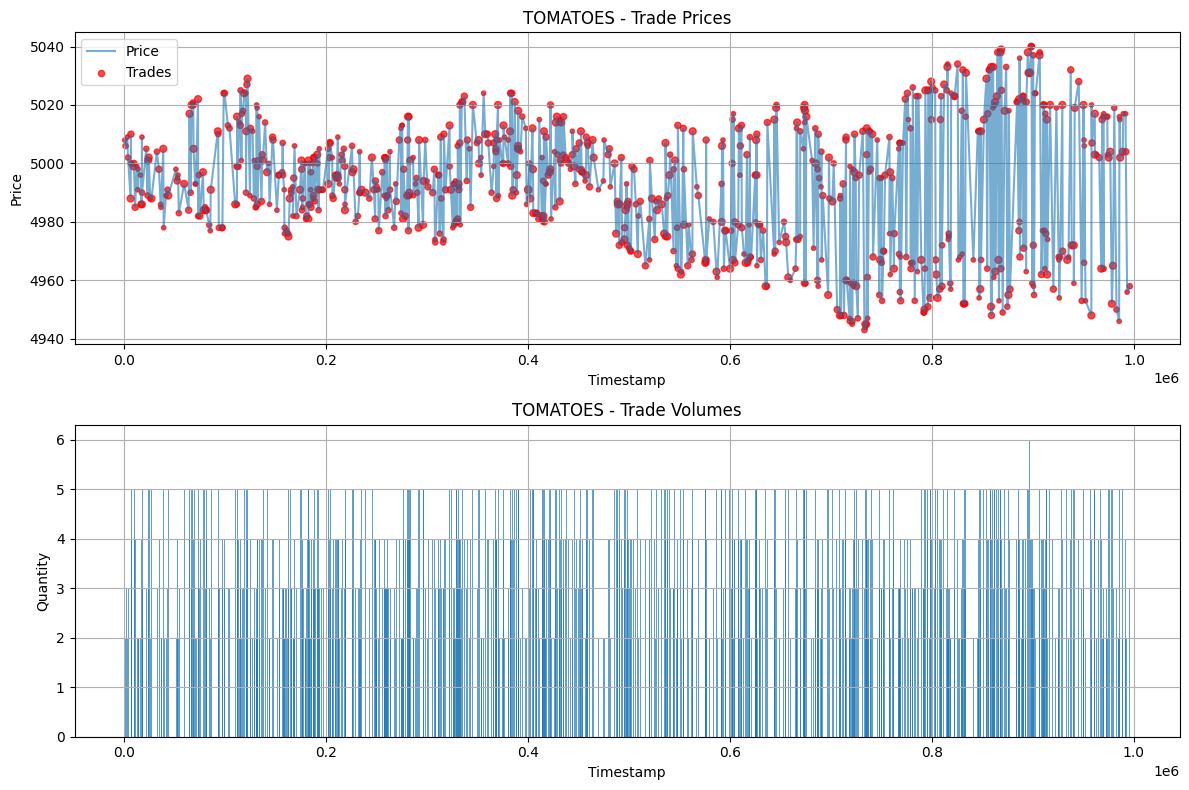

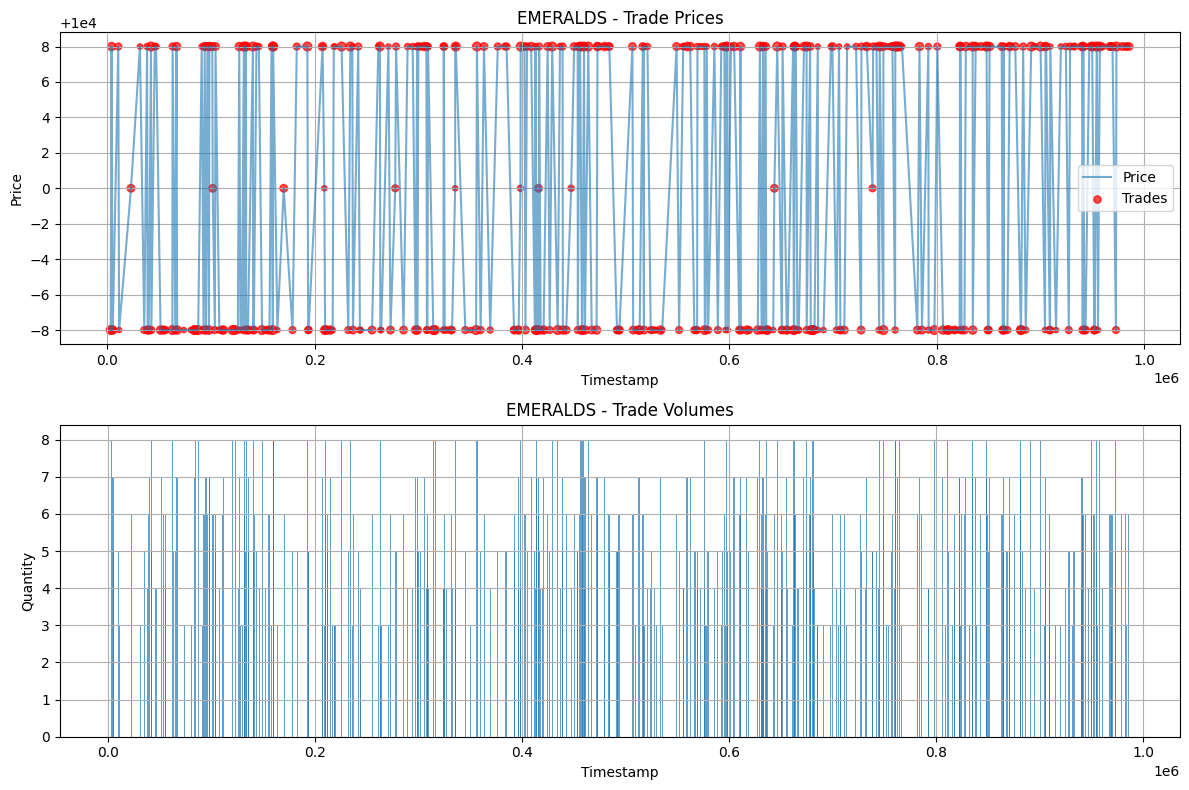

In [47]:
# Plot trade prices over time
def plot_trades(data, symbol):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    
    # Trade prices (line + trade markers)
    ax1.plot(data['timestamp'], data['price'], alpha=0.6, label="Price")

    # Scatter points for trades
    ax1.scatter(
        data['timestamp'],
        data['price'],
        s=data['quantity'] * 5,
        alpha=0.7,
        color='red',
        label="Trades"
    )

    ax1.set_title(f'{symbol} - Trade Prices')
    ax1.set_xlabel('Timestamp')
    ax1.set_ylabel('Price')
    ax1.grid(True)
    ax1.legend()

    
    # Trade volumes
    ax2.bar(data['timestamp'], data['quantity'], width=1000, alpha=0.7)
    ax2.set_title(f'{symbol} - Trade Volumes')
    ax2.set_xlabel('Timestamp')
    ax2.set_ylabel('Quantity')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

plot_trades(tomatoes_trades, 'TOMATOES')
plot_trades(emeralds_trades, 'EMERALDS')

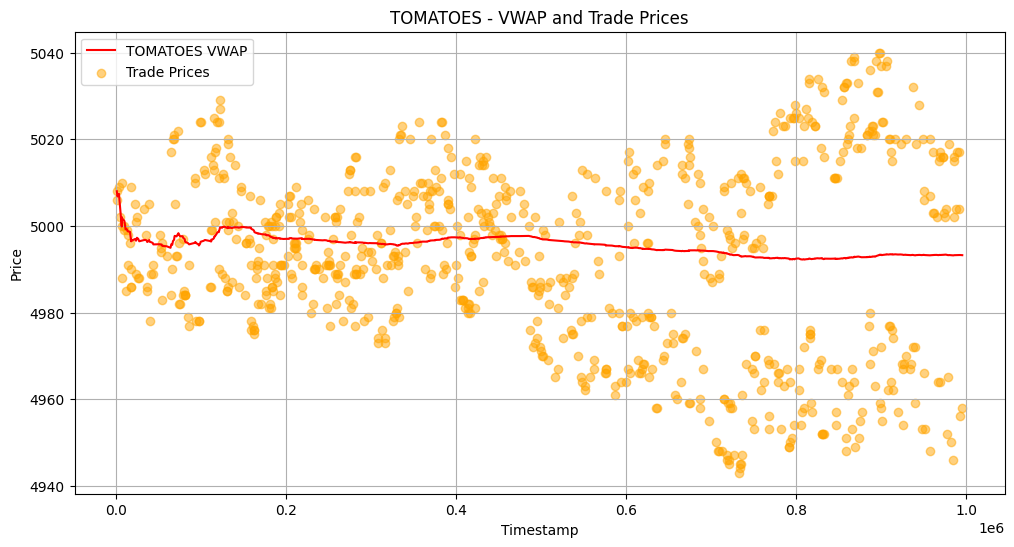

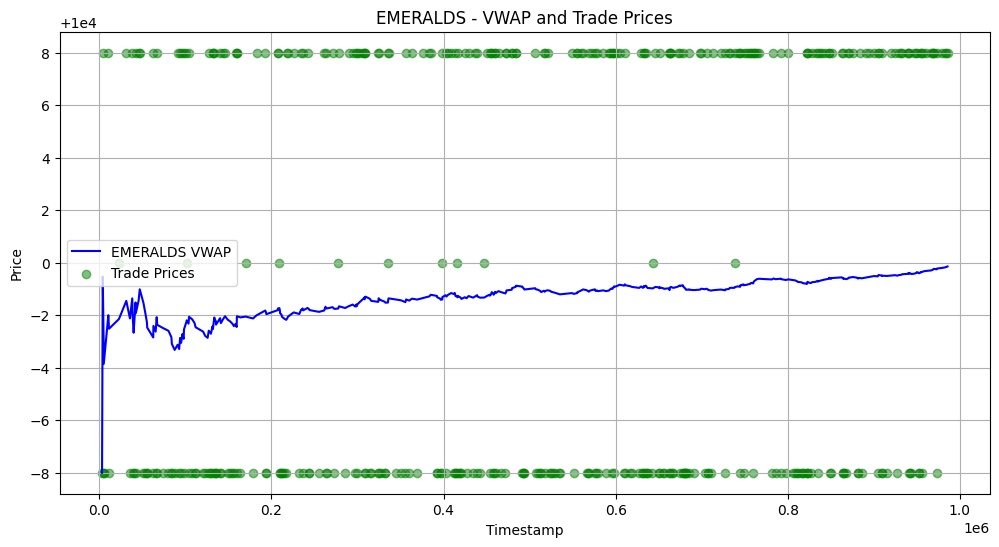

In [48]:
# Calculate VWAP (Volume Weighted Average Price)
def calculate_vwap(trades):
    trades = trades.sort_values('timestamp')
    trades['cum_volume'] = trades['quantity'].cumsum()
    trades['cum_price_volume'] = (trades['price'] * trades['quantity']).cumsum()
    trades['vwap'] = trades['cum_price_volume'] / trades['cum_volume']
    return trades

tomatoes_trades = calculate_vwap(tomatoes_trades)
emeralds_trades = calculate_vwap(emeralds_trades)

# Plot VWAP
plt.figure(figsize=(12, 6))
plt.plot(tomatoes_trades['timestamp'], tomatoes_trades['vwap'], label='TOMATOES VWAP', color='red')
plt.scatter(tomatoes_trades['timestamp'], tomatoes_trades['price'], alpha=0.5, label='Trade Prices', color='orange')
plt.title('TOMATOES - VWAP and Trade Prices')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(emeralds_trades['timestamp'], emeralds_trades['vwap'], label='EMERALDS VWAP', color='blue')
plt.scatter(emeralds_trades['timestamp'], emeralds_trades['price'], alpha=0.5, label='Trade Prices', color='green')
plt.title('EMERALDS - VWAP and Trade Prices')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

TOMATOES Trades Statistics:
             price    quantity
count   820.000000  820.000000
mean   4992.571951    3.479268
std      21.130467    1.120705
min    4943.000000    2.000000
25%    4978.000000    2.000000
50%    4994.000000    3.000000
75%    5008.000000    4.000000
max    5040.000000    6.000000

EMERALDS Trades Statistics:
              price    quantity
count    399.000000  399.000000
mean    9999.799499    5.486216
std        7.896307    1.625545
min     9992.000000    3.000000
25%     9992.000000    4.000000
50%    10000.000000    6.000000
75%    10008.000000    7.000000
max    10008.000000    8.000000


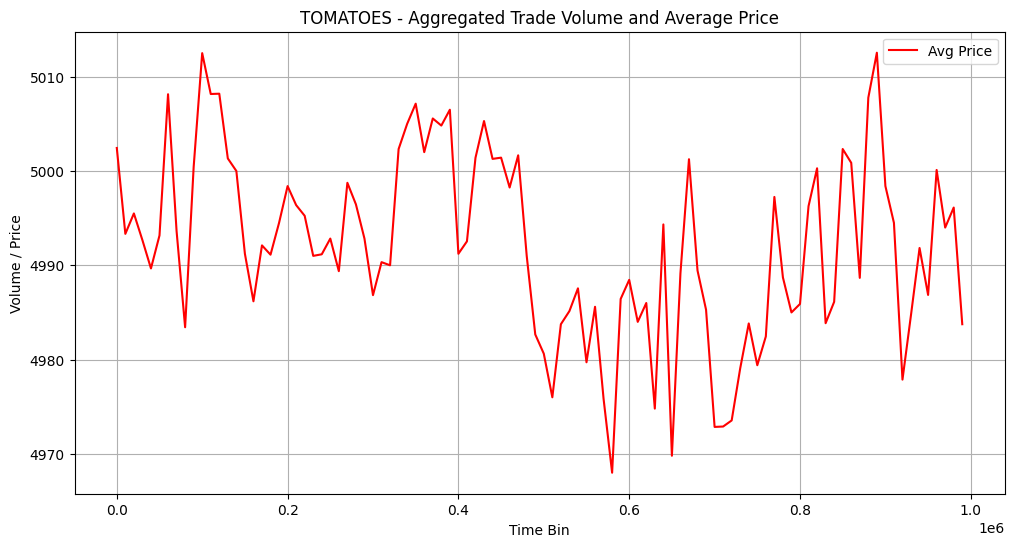

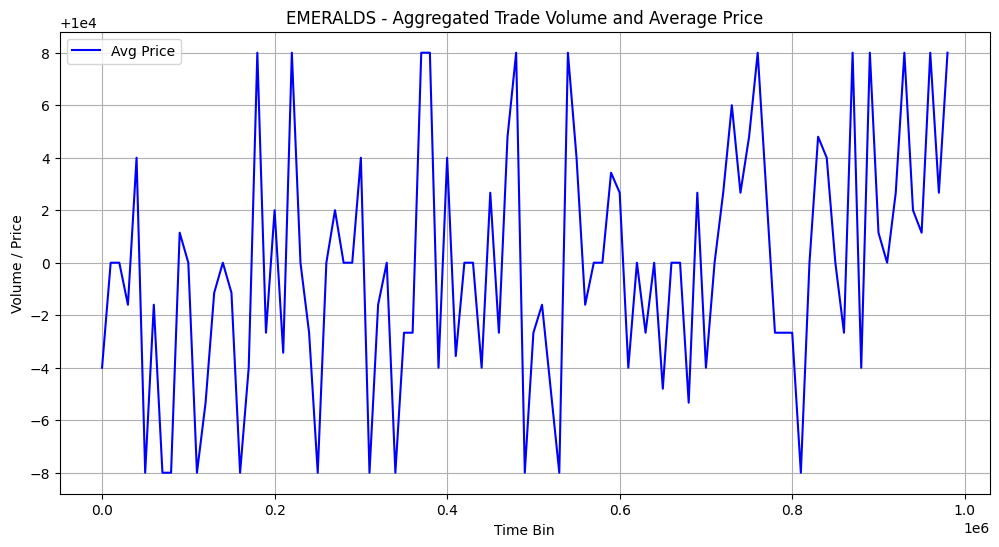

In [50]:
# Trade statistics
print("TOMATOES Trades Statistics:")
print(tomatoes_trades[['price', 'quantity']].describe())
print("\nEMERALDS Trades Statistics:")
print(emeralds_trades[['price', 'quantity']].describe())

# Trade volume over time (aggregated)
def aggregate_trades(trades, window=10000):  # 10 second windows
    trades['time_bin'] = (trades['timestamp'] // window) * window
    agg = trades.groupby('time_bin').agg({
        'quantity': 'sum',
        'price': 'mean'
    }).reset_index()
    return agg

tom_agg = aggregate_trades(tomatoes_trades)
eme_agg = aggregate_trades(emeralds_trades)

plt.figure(figsize=(12, 6))
# plt.bar(tom_agg['time_bin'], tom_agg['quantity'], width=8000, alpha=0.7, label='Volume')
plt.plot(tom_agg['time_bin'], tom_agg['price'], color='red', label='Avg Price')
plt.title('TOMATOES - Aggregated Trade Volume and Average Price')
plt.xlabel('Time Bin')
plt.ylabel('Volume / Price')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
# plt.bar(eme_agg['time_bin'], eme_agg['quantity'], width=8000, alpha=0.7, label='Volume')
plt.plot(eme_agg['time_bin'], eme_agg['price'], color='blue', label='Avg Price')
plt.title('EMERALDS - Aggregated Trade Volume and Average Price')
plt.xlabel('Time Bin')
plt.ylabel('Volume / Price')
plt.legend()
plt.grid(True)
plt.show()